In [1]:
#  IMPORTS & LOAD RAW DATA

import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.validation import make_valid
from shapely.geometry import MultiPolygon
from itertools import combinations

path = r"C:\Users\INBA\Desktop\OneDrive - ELCOT\Inba\Anudip\Project\EV_Highway_Corridor_Reliability_Gap_Analysis\data\Raw datasets\States_and_Union_Territories.parquet"
states = gpd.read_parquet(path)
states.head()

,OBJECTID,STNAME,STCODE11,State_LGD,Remarks,STNAME_SH,InPoly_FID,SimPgnFlag,MaxSimpTol,MinSimpTol,Shape_Length,Shape_Area,geometry
0,18,LAKSHADWEEP,31,31,Lakshadweep,LAKSHADWEEP,18,0,100,100,1.458872e+05,3.113286e+07,"MULTIPOLYGON (((73.0132 8.30322, 73.01312 8.30..."
1,16,KERALA,32,32,Kerala,KERALA,16,0,100,100,1.888184e+06,4.046073e+10,"POLYGON ((74.99682 12.78912, 74.99724 12.78911..."
2,25,PUDUCHERRY,34,34,Puducherry,PUDUCHERRY,25,0,100,100,5.548237e+05,5.303626e+08,"MULTIPOLYGON (((79.80913 10.87788, 79.80738 10..."
3,29,TAMIL NADU,33,33,Tamil nadu,TAMIL NADU,29,0,100,100,3.691262e+06,1.358468e+11,"MULTIPOLYGON (((78.21 8.83922, 78.21009 8.8391..."
4,35,KARNATAKA,29,29,Karnataka,KARNATAKA,35,0,100,100,4.851482e+06,2.064008e+11,"MULTIPOLYGON (((74.24167 14.71151, 74.2418 14...."


In [2]:
df = states.copy()

In [3]:
# BASIC INFO & STRUCTURE

df.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   OBJECTID      36 non-null     int32   
 1   STNAME        36 non-null     str     
 2   STCODE11      36 non-null     str     
 3   State_LGD     36 non-null     int32   
 4   Remarks       36 non-null     str     
 5   STNAME_SH     36 non-null     str     
 6   InPoly_FID    36 non-null     int32   
 7   SimPgnFlag    36 non-null     int32   
 8   MaxSimpTol    36 non-null     int32   
 9   MinSimpTol    36 non-null     int32   
 10  Shape_Length  36 non-null     float64 
 11  Shape_Area    36 non-null     float64 
 12  geometry      36 non-null     geometry
dtypes: float64(2), geometry(1), int32(6), str(4)
memory usage: 4.1 KB


In [4]:
print("Shape:",df.shape)
print("Columns:",df.columns.tolist())
print(df.crs)

Shape: (36, 13)
Columns: ['OBJECTID', 'STNAME', 'STCODE11', 'State_LGD', 'Remarks', 'STNAME_SH', 'InPoly_FID', 'SimPgnFlag', 'MaxSimpTol', 'MinSimpTol', 'Shape_Length', 'Shape_Area', 'geometry']
OGC:CRS84


In [5]:
# CHECK MISSING VALUES

df.isnull().sum()

OBJECTID        0
STNAME          0
STCODE11        0
State_LGD       0
Remarks         0
STNAME_SH       0
InPoly_FID      0
SimPgnFlag      0
MaxSimpTol      0
MinSimpTol      0
Shape_Length    0
Shape_Area      0
geometry        0
dtype: int64

In [6]:
# CHECK DUPLICATES

print("Duplicate rows:", states.duplicated().sum())

Duplicate rows: 0


In [7]:
print("Duplicate state names:", states["STNAME"].duplicated().sum())

Duplicate state names: 0


In [8]:
# GEOMETRY VALIDATION

print("Duplicate states:", df["STNAME"].duplicated().sum())
print("Empty geometries:", df.geometry.is_empty.sum())
print("Invalid geometries:", (~df.geometry.is_valid).sum())
print(df.geom_type.value_counts())

Duplicate states: 0
Empty geometries: 0
Invalid geometries: 3
Polygon         20
MultiPolygon    16
Name: count, dtype: int64


In [9]:
# Fix invalid geometries

df["geometry"] = df.geometry.apply(lambda g: make_valid(g) if not g.is_valid else g)

In [10]:
# CLEAN & STANDARDIZE STATE NAMES

df = df[["STNAME", "STCODE11", "State_LGD", "geometry"]]

In [11]:
df = df.rename(columns={
    "STNAME": "state",
    "STCODE11": "state_code",
    "State_LGD": "lgd_code"
})

In [12]:
# Clean state names

df["state"] = (df["state"]
               .str.strip()
               .str.title()
               .str.replace("&", "and", regex=False)
               .str.replace(r"\s+", " ", regex=True))

# Fix specific names
df["state"] = df["state"].replace({
    "Dadra,Nagar Haveli,Daman and Diu": "Dadra and Nagar Haveli and Daman and Diu",
    "Andaman and Nicobar": "Andaman and Nicobar Islands"
})

In [13]:
# Add lowercase key

df["state_key"]=df["state"].str.lower()

In [14]:
df.dtypes

state              str
state_code         str
lgd_code         int32
geometry      geometry
state_key          str
dtype: object

In [15]:
df["state_code"] = df["state_code"].astype(int)
print(df.dtypes)

state              str
state_code       int64
lgd_code         int32
geometry      geometry
state_key          str
dtype: object


In [16]:
df.head()

,state,state_code,lgd_code,geometry,state_key
0,Lakshadweep,31,31,"MULTIPOLYGON (((73.0132 8.30322, 73.01312 8.30...",lakshadweep
1,Kerala,32,32,"POLYGON ((74.99682 12.78912, 74.99724 12.78911...",kerala
2,Puducherry,34,34,"MULTIPOLYGON (((79.80913 10.87788, 79.80738 10...",puducherry
3,Tamil Nadu,33,33,"MULTIPOLYGON (((78.21 8.83922, 78.21009 8.8391...",tamil nadu
4,Karnataka,29,29,"MULTIPOLYGON (((74.24167 14.71151, 74.2418 14....",karnataka


In [17]:
df = df.sort_values("state").reset_index(drop=True)

In [18]:
# Basic checks
print(df["state_code"].is_unique, df["lgd_code"].is_unique)   
print(df["state_code"].min(), df["state_code"].max())          
print(df["lgd_code"].min(), df["lgd_code"].max())

True True
1 39
1 38


In [19]:
print(df["lgd_code"].is_unique)

True


In [20]:
print(df["state_code"].is_unique)   # True 0

True


In [21]:
if df["lgd_code"].between(1, 40).all():
    print("True: all LGD codes are valid")
else:
    print("False")

True: all LGD codes are valid


In [22]:
if df["state_code"].between(1, 40).all():
    print("True: all State codes are valid")
else:
    print("False")

True: all State codes are valid


In [23]:
print(df.geom_type.value_counts())
print(df.is_valid.all())

Polygon         20
MultiPolygon    16
Name: count, dtype: int64
True


In [24]:
# GEOMETRY CLEANUP

def keep_polygons(g):
    if g.geom_type == "GeometryCollection":
        polys = [p for p in g.geoms if p.geom_type in ("Polygon", "MultiPolygon")]
        return MultiPolygon([q for p in polys for q in (p.geoms if p.geom_type == "MultiPolygon" else [p])])
    return g
df["geometry"] = df.geometry.apply(keep_polygons)

In [25]:
print(df.crs)

OGC:CRS84


In [26]:
print(df.total_bounds)   # roughly [68, 6, 98, 38]
b = df.geometry.bounds
print(df[(b.minx < 67) | (b.maxx > 98) | (b.miny < 6) | (b.maxy > 38)][["state"]])   

[68.1775119  6.7527826 97.4128965 37.0883418]
Empty DataFrame
Columns: [state]
Index: []


In [27]:
# AREA CALCULATION

proj = df.to_crs(epsg=7755)
overlaps = []
for (i, a), (j, c) in combinations(proj.iterrows(), 2):
    if a.geometry.intersects(c.geometry):
        area = a.geometry.intersection(c.geometry).area / 1e6
        if area > 1:
            overlaps.append((a.state, c.state, round(area, 2)))
print(overlaps)   # expect []

[]


In [28]:
# MULTIPART GEOMETRIES

df["n_parts"] = df.geometry.apply(lambda g: len(g.geoms) if g.geom_type == "MultiPolygon" else 1)
print(df[["state", "n_parts"]].sort_values("n_parts", ascending=False).head(8))

# Any parts smaller than 1 km² (islands are expected; check they make sense)
tiny = []
for _, r in proj.iterrows():
    parts = r.geometry.geoms if r.geometry.geom_type == "MultiPolygon" else [r.geometry]
    tiny += [(r.state, round(p.area / 1e6, 4)) for p in parts if p.area / 1e6 < 1]
print(len(tiny), tiny[:10])

                          state  n_parts
0   Andaman and Nicobar Islands      606
30                   Tamil Nadu       38
35                  West Bengal       38
18                  Lakshadweep       27
10                      Gujarat       23
26                   Puducherry       22
25                       Odisha       21
15                    Karnataka       13
637 [('Andaman and Nicobar Islands', 0.0795), ('Andaman and Nicobar Islands', 0.0558), ('Andaman and Nicobar Islands', 0.009), ('Andaman and Nicobar Islands', 0.0075), ('Andaman and Nicobar Islands', 0.0552), ('Andaman and Nicobar Islands', 0.0262), ('Andaman and Nicobar Islands', 0.0068), ('Andaman and Nicobar Islands', 0.7049), ('Andaman and Nicobar Islands', 0.91), ('Andaman and Nicobar Islands', 0.5531)]


In [29]:
union = proj.geometry.union_all()
print(union.geom_type)   # MultiPolygon (mainland + islands)

MultiPolygon


In [30]:

coords = np.concatenate([np.array(g.exterior.coords) if g.geom_type == "Polygon"
                         else np.concatenate([np.array(p.exterior.coords) for p in g.geoms])
                         for g in df.geometry])
print(np.isnan(coords).any(), np.isinf(coords).any())   # False False

False False


In [31]:
assert df.geometry.notna().all()
assert (~df.geometry.is_empty).all()
assert df.geometry.is_valid.all()
assert df.geom_type.isin(["Polygon", "MultiPolygon"]).all()
assert str(df.crs) in ("OGC:CRS84", "EPSG:4326")
print("All geometry checks passed")

All geometry checks passed


In [32]:
proj = df.to_crs(epsg=7755)                       # India LCC, metres
df["area_km2"] = (proj.geometry.area / 1e6).round(2)

In [33]:
print(df["area_km2"].dtype)                        
print("Nulls:", df["area_km2"].isna().sum())       
print("Zero/negative:", (df["area_km2"] <= 0).sum())   
print("Infinite:", np.isinf(df["area_km2"]).sum()) 
print(df["area_km2"].describe())
print("Total India area:", df["area_km2"].sum().round(0))

float64
Nulls: 0
Zero/negative: 0
Infinite: 0
count        36.000000
mean      88302.297500
std       92187.693248
min          30.370000
25%       14490.062500
50%       54442.820000
75%      136125.930000
max      329892.470000
Name: area_km2, dtype: float64
Total India area: 3178883.0


In [34]:
assert df["area_km2"].notna().all(), "Null area"
assert (df["area_km2"] > 0).all(), "Non-positive area"
assert 3.0e6 < df["area_km2"].sum() < 3.6e6, "Total area out of range"
print("All area checks passed")

All area checks passed


(36, 7)
OGC:CRS84
0
True
True


<Axes: >

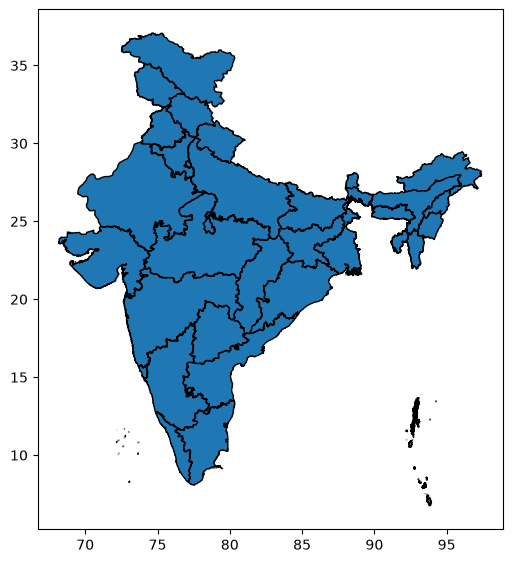

In [35]:
print(df.shape)                       
print(df.crs)
print(df.isna().sum().sum())          
print(df["state"].is_unique)          
print(df.geometry.is_valid.all())     
df.plot(figsize=(6, 7), edgecolor="black")

In [36]:
# FINAL CLEANING & EXPORT

save_path = r"C:\Users\INBA\Desktop\OneDrive - ELCOT\Inba\Anudip\Project\EV_Highway_Corridor_Reliability_Gap_Analysis\data\Cleaned datasets\states_clean.parquet"
df.to_parquet(save_path)

In [37]:
df.head(10)


,state,state_code,lgd_code,geometry,state_key,n_parts,area_km2
0,Andaman and Nicobar Islands,35,35,"MULTIPOLYGON (((92.52549 10.89614, 92.52608 10...",andaman and nicobar islands,606,7838.45
1,Andhra Pradesh,37,28,"POLYGON ((84.67777 19.16652, 84.67778 19.16639...",andhra pradesh,1,159974.18
2,Arunachal Pradesh,12,12,"POLYGON ((96.14817 29.38679, 96.14946 29.38365...",arunachal pradesh,1,79339.18
3,Assam,18,18,"POLYGON ((95.86998 27.96882, 95.87808 27.96833...",assam,1,75549.53
4,Bihar,10,10,"POLYGON ((84.10926 27.52077, 84.10945 27.52045...",bihar,1,90616.35
5,Chandigarh,4,4,"POLYGON ((76.77233 30.79414, 76.77291 30.79331...",chandigarh,1,111.86
6,Chhattisgarh,22,22,"POLYGON ((83.34603 24.09744, 83.34775 24.09629...",chhattisgarh,1,130355.28
7,Dadra and Nagar Haveli and Daman and Diu,39,38,"MULTIPOLYGON (((71.14967 20.7712, 71.14949 20....",dadra and nagar haveli and daman and diu,6,579.76
8,Delhi,7,7,"POLYGON ((77.10117 28.8706, 77.10244 28.87057,...",delhi,1,1437.68
9,Goa,30,30,"MULTIPOLYGON (((74.08555 14.89844, 74.08528 14...",goa,3,3634.01
